# 📚 Tarea Semana 5: Reconocimiento de Locutor con Redes Neuronales Recurrentes (RNN)

---

> **Estudiante:** Oscar Mauricio Garcia Mesa
> **Asignatura:** Redes Neuronales
> **Objetivo:** Clasificar voces de 3 personas (Gilmer, Mario, Oscar) y silencio
> usando una Red Neuronal Recurrente (LSTM) entrenada con características MFCC.

## Introducción

El **reconocimiento de locutor** y el **reconocimiento de voz** son dos campos distintos pero relacionados dentro del dominio más amplio del procesamiento y análisis de señales de audio. A continuación, se presentan las principales diferencias entre ellos:

1. **Objetivo:**
   - **Reconocimiento de locutor:** El objetivo principal es identificar o verificar la identidad de un hablante en función de sus características vocales únicas, conocidas como "huellas de voz" o "firmas biométricas". Es una forma de autenticación biométrica.
   - **Reconocimiento de voz:** El objetivo principal es convertir el lenguaje hablado en texto u otros tipos de comandos.

2. **Enfoque:**
   - **Reconocimiento de locutor:** Se centra en las características únicas de la voz de una persona, como el tono, timbre, acento y patrones de habla, para establecer su identidad.
   - **Reconocimiento de voz:** Se centra en comprender e interpretar el contenido lingüístico de las palabras habladas.

3. **Aplicaciones:**
   - **Reconocimiento de locutor:** Se utiliza en sistemas de seguridad, control de acceso y autenticación biométrica.
   - **Reconocimiento de voz:** Se aplica en asistentes activados por voz, servicios de transcripción y comandos de voz.

4. **Técnicas:**
   - **Reconocimiento de locutor:** Utiliza extracción de características y emparejamiento de patrones.
   - **Reconocimiento de voz:** Utiliza HMM, DNN y RNN para modelado acústico y lingüístico.

## Planteamiento del Problema

En este proyecto contamos con **grabaciones de audio de 4 clases**:

| Clase | Descripción | Fragmentos de 1 segundo |
|-------|-------------|------------------------|
| **Gilmer** | Voz del locutor Gilmer | 35 |
| **Mario** | Voz del locutor Mario | 30 |
| **Oscar** | Voz del locutor Oscar (estudiante) | 103 |
| **Silencio** | Grabaciones de silencio / ruido de fondo | 35 |

El objetivo es entrenar un modelo **RNN (Red Neuronal Recurrente con LSTM)** capaz de predecir a qué clase pertenece un fragmento de audio de 1 segundo.

Las **Redes Neuronales Recurrentes (RNN)** son especialmente adecuadas para el reconocimiento de locutor porque:
- Modelan **dependencias secuenciales** en el tiempo.
- Capturan **patrones temporales** en los datos de audio.
- Las células LSTM (Long Short-Term Memory) pueden recordar información relevante a largo plazo y olvidar la irrelevante.

## IMPORTANDO LIBRERÍAS

In [14]:
# Importando librerías principales

import numpy as np       # Operaciones numéricas y manejo de arrays multidimensionales
import pandas as pd      # Manipulación de datos tabulares (DataFrames)
import os                # Proporciona funciones para interactuar con el sistema operativo (rutas, directorios, archivos)
import shutil            # Permite copiar, mover o eliminar archivos y directorios de forma sencilla
import matplotlib.pyplot as plt  # Biblioteca de visualización de datos (gráficas)

## Crear archivos de audio combinados para visualización

Quiero combinar los **primeros fragmentos** de los archivos de audio de cada locutor en un único archivo largo para poder escucharlos y visualizarlos fácilmente.

Estoy utilizando una carpeta de **salida local** para guardar los archivos combinados.
Usaré los fragmentos de 1 segundo ya procesados en `../dataset_voces_procesado/`.

In [15]:
import os
import shutil

# Ruta local de salida donde se guardarán los archivos combinados por locutor
# os.path.join construye la ruta de forma compatible con cualquier sistema operativo
output_dir = os.path.join("combined_audios")

# shutil.rmtree elimina el directorio y todo su contenido (si ya existe)
# ignore_errors=True evita que el programa falle si el directorio no existe todavía
shutil.rmtree(output_dir, ignore_errors=True)

# os.makedirs crea el directorio (y sus subdirectorios si es necesario)
# exist_ok=True evita un error si el directorio ya existe
os.makedirs(output_dir, exist_ok=True)

print(f"✅ Directorio {output_dir} limpiado y listo para nuevos archivos.")

✅ Directorio combined_audios limpiado y listo para nuevos archivos.


## Crear archivos combinados para cada locutor

Usamos los paquetes **librosa** y **soundfile** para crear los archivos combinados.

Tomamos los **primeros 30 fragmentos** de cada carpeta de locutor para crear aproximadamente **30 segundos de audio** de cada clase (suficiente para visualización).

- **librosa**: paquete de Python para el análisis de música y audio. Proporciona herramientas para extraer características, representar series de tiempo y visualizar señales de audio. Es ampliamente utilizado en recuperación de información musical y procesamiento de señales.

- **soundfile**: librería de Python para leer y escribir archivos de sonido. Ofrece una interfaz sencilla que soporta formatos WAV, FLAC y OGG. Se usa junto con **librosa** al trabajar con datos de audio.

## 🎯 Objetivo del código de combinación

1. Define la ruta al dataset procesado de fragmentos de 1 segundo (`../dataset_voces_procesado`).
2. Crea un directorio de salida (`combined_audios`) para guardar los resultados.
3. Recorre las carpetas de los 4 locutores.
4. De cada locutor, carga los primeros 30 fragmentos (`0.wav` a `29.wav`).
5. Concatena los fragmentos en una sola secuencia de audio por locutor.
6. Guarda el archivo final combinado en formato `.wav`.
7. Al final se obtiene **un único archivo de audio por locutor** de ≈30 segundos de duración.

In [16]:
import os
import librosa      # Librería para análisis y procesamiento de audio
import soundfile as sf  # Librería para leer y escribir archivos de audio

# ── Ruta al dataset de fragmentos procesados (carpeta padre de los locutores) ──
# Se usa '../' para salir de la carpeta 'tarea/' y acceder a 'Semana 5/'
dataset_path = os.path.join("..", "dataset_voces_procesado")

# ── Directorio de salida para los archivos combinados ──
output_dir = os.path.join("combined_audios")

# os.makedirs crea el directorio si no existe (exist_ok=True evita error si ya existe)
os.makedirs(output_dir, exist_ok=True)

# ── Lista de carpetas con el nombre de cada clase ──
# Deben coincidir EXACTAMENTE con los nombres de las subcarpetas en dataset_voces_procesado
speaker_folders = [
    "Gilmer",
    "Mario",
    "Oscar",
    "Silencio"
]

# ── Número de fragmentos .wav a combinar por locutor ──
# 30 fragmentos × 1 segundo = 30 segundos de audio por clase
num_files_to_combine = 30

# ── Itera sobre cada carpeta de locutor ──
for speaker_folder in speaker_folders:

    # Construye la ruta completa a la carpeta del locutor
    speaker_folder_path = os.path.join(dataset_path, speaker_folder)

    # Genera la lista de nombres de archivos a combinar: ["0.wav", "1.wav", ..., "29.wav"]
    wav_files = [f"{i}.wav" for i in range(num_files_to_combine)]

    combined_audio = []  # Lista vacía donde se irán acumulando los fragmentos de audio
    sr = None            # Variable para almacenar la frecuencia de muestreo

    # ── Itera sobre cada fragmento y lo concatena ──
    for wav_file in wav_files:

        # Ruta completa al fragmento actual
        wav_file_path = os.path.join(speaker_folder_path, wav_file)

        if not os.path.exists(wav_file_path):
            # Si el fragmento no existe (p.ej. el locutor tiene menos de 30 fragmentos), lo saltamos
            continue

        # librosa.load carga el archivo de audio:
        #   - sr=None → preserva la frecuencia de muestreo original del archivo
        #   - Devuelve: audio (array de muestras) y sr (frecuencia de muestreo en Hz)
        audio, sr = librosa.load(wav_file_path, sr=None)

        # list.extend() añade todos los elementos de 'audio' al final de 'combined_audio'
        combined_audio.extend(audio)

    # ── Guarda el audio combinado como un único archivo .wav ──
    # Ruta de salida: p.ej. combined_audios/Gilmer_combined.wav
    output_file_path = os.path.join(output_dir, f"{speaker_folder}_combined.wav")

    # sf.write escribe el array de audio en disco con la frecuencia de muestreo 'sr'
    sf.write(output_file_path, combined_audio, sr)
    print(f"✅ {speaker_folder}_combined.wav guardado ({len(combined_audio)/sr:.1f} seg)")

print("\n✅ Combinación completa. Archivos guardados en:", output_dir)

✅ Gilmer_combined.wav guardado (30.0 seg)
✅ Mario_combined.wav guardado (30.0 seg)
✅ Oscar_combined.wav guardado (30.0 seg)
✅ Silencio_combined.wav guardado (30.0 seg)

✅ Combinación completa. Archivos guardados en: combined_audios


**IPython** es una **consola interactiva de línea de comandos para Python**.
Proporciona un entorno interactivo mejorado, especialmente popular entre científicos de datos e investigadores.
Con `IPython.display.Audio` podemos incrustar reproductores de audio directamente en el notebook. ✅

In [17]:
import os
from IPython.display import display, Audio

# Ruta al directorio donde se guardaron los audios combinados
output_dir = os.path.join("combined_audios")

# ── Función para reproducir un archivo de audio en el notebook ──
def play_audio(audio_path):
    # display() renderiza objetos enriquecidos en la celda de salida del notebook.
    # Audio(filename=...) crea un widget reproductor para el archivo indicado.
    display(Audio(filename=audio_path))

# ── Reproduce el audio combinado del locutor Gilmer ──
speaker_file = "Gilmer_combined.wav"
audio_path = os.path.join(output_dir, speaker_file)
print(f"Haz clic en el botón para escuchar: {audio_path}")
play_audio(audio_path)  # Inserta el reproductor de audio en la celda

Haz clic en el botón para escuchar: combined_audios\Gilmer_combined.wav


In [18]:
import os
from IPython.display import display, Audio

output_dir = os.path.join("combined_audios")

def play_audio(audio_path):
    display(Audio(filename=audio_path))

# ── Reproduce el audio combinado del locutor Oscar ──
speaker_file = "Oscar_combined.wav"
audio_path = os.path.join(output_dir, speaker_file)
print(f"Haz clic en el botón para escuchar: {audio_path}")
play_audio(audio_path)

Haz clic en el botón para escuchar: combined_audios\Oscar_combined.wav


In [19]:
import os
from IPython.display import display, Audio

output_dir = os.path.join("combined_audios")

def play_audio(audio_path):
    display(Audio(filename=audio_path))

# ── Reproduce el audio combinado del locutor Oscar ──
speaker_file = "Mario_combined.wav"
audio_path = os.path.join(output_dir, speaker_file)
print(f"Haz clic en el botón para escuchar: {audio_path}")
play_audio(audio_path)

Haz clic en el botón para escuchar: combined_audios\Mario_combined.wav


## 📊 VISUALIZACIONES DE DATOS DE AUDIO

Existen varias formas de representar gráficamente una señal de audio. Las más comunes son la **forma de onda**, el **espectrograma** y los **MFCCs**.

---

### 🎵 1. Forma de onda (*Waveform*)
- **Qué es:** Representación en el **dominio del tiempo**.
- **Ejes:** Eje X = tiempo, Eje Y = amplitud (volumen).
- **Qué muestra:** Cómo cambia la intensidad del sonido a lo largo del tiempo.
- **Interpretación:** Los **picos** son momentos de mayor volumen (habla activa); los valles planos son silencios o pausas.

---

### 🎼 2. Espectrograma (*Spectrogram*)
- **Qué es:** Representación en el **dominio de la frecuencia**.
- **Ejes:** Eje X = tiempo, Eje Y = frecuencia (Hz), Color = energía (dB).
- **Qué muestra:** Qué frecuencias están presentes en cada instante de tiempo.
- **Interpretación:** Las zonas más brillantes (colores cálidos) indican frecuencias con mayor energía. Las voces graves tienen energía en frecuencias bajas; las agudas, en altas.

---

### 🎙️ 3. MFCCs (*Mel-Frequency Cepstral Coefficients*)
Los MFCCs son la representación que usaremos para **entrenar el modelo**.

- **Ejes del gráfico:** Eje X = tiempo, Eje Y = coeficientes MFCC (0–12).
- **Qué capturan:** La forma del tracto vocal durante la producción del sonido.
- **Por qué son útiles:** Simulan cómo el oído humano percibe el sonido, eliminando información irrelevante y conservando lo esencial de la voz.
- **Aplicaciones:** Reconocimiento de voz, identificación de locutor, detección de emociones.

---

👉 Resumen:
- La **forma de onda** muestra la intensidad en el tiempo.
- El **espectrograma** revela cómo cambian las frecuencias.
- Los **MFCCs** extraen características únicas de la voz para análisis con ML.

👉 "Ahora veremos las tres gráficas para cada una de las 4 clases de nuestro dataset."

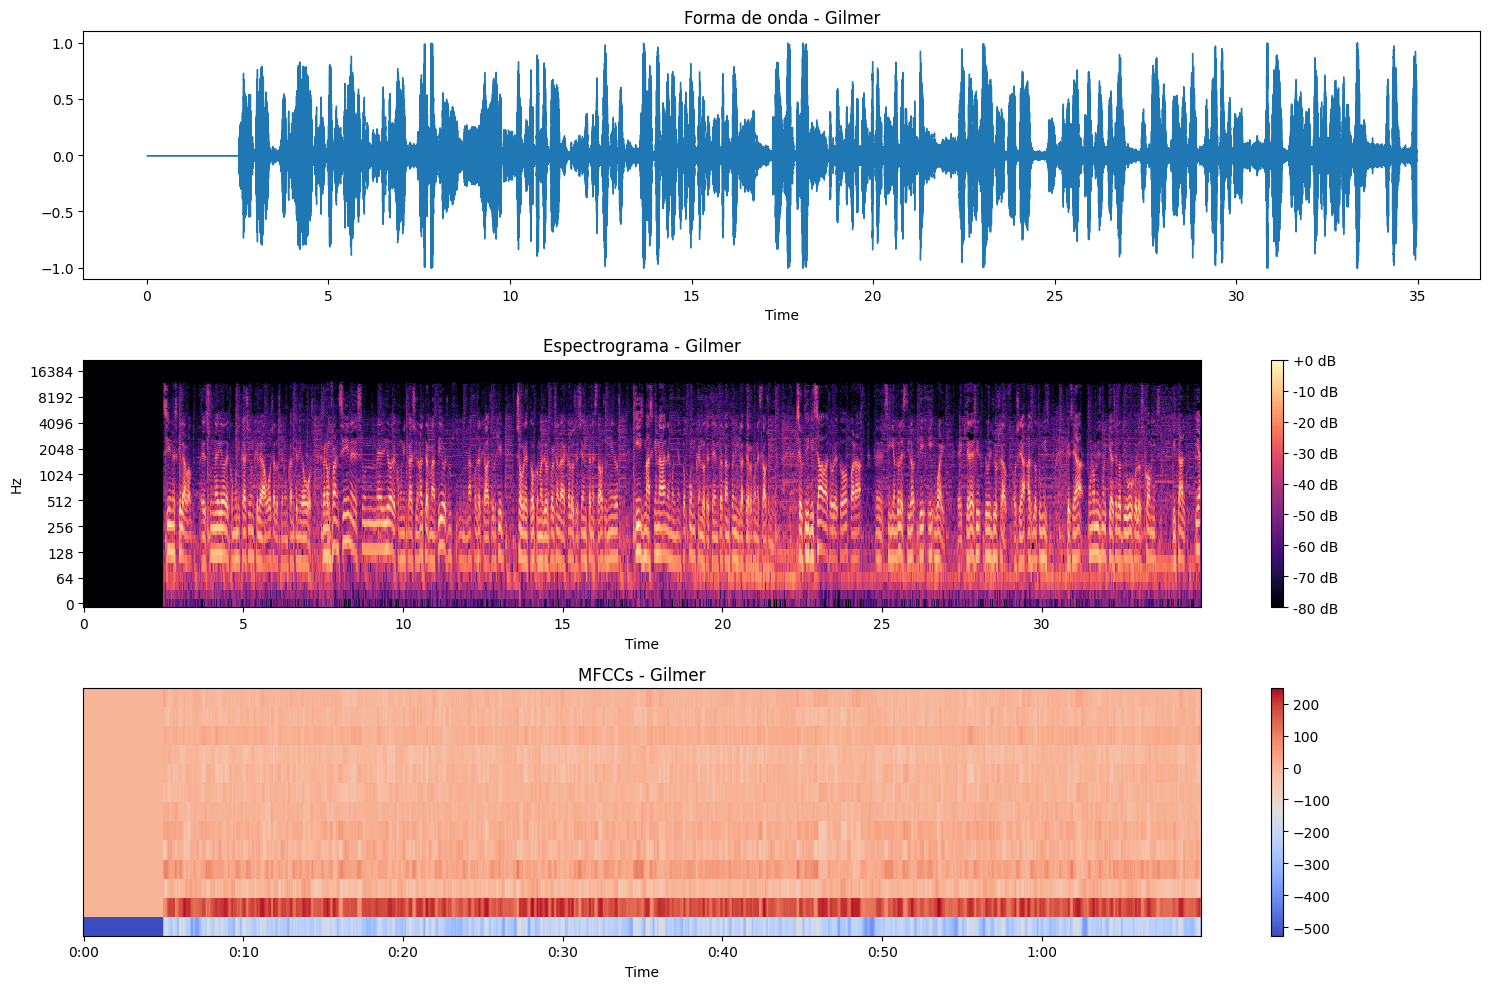

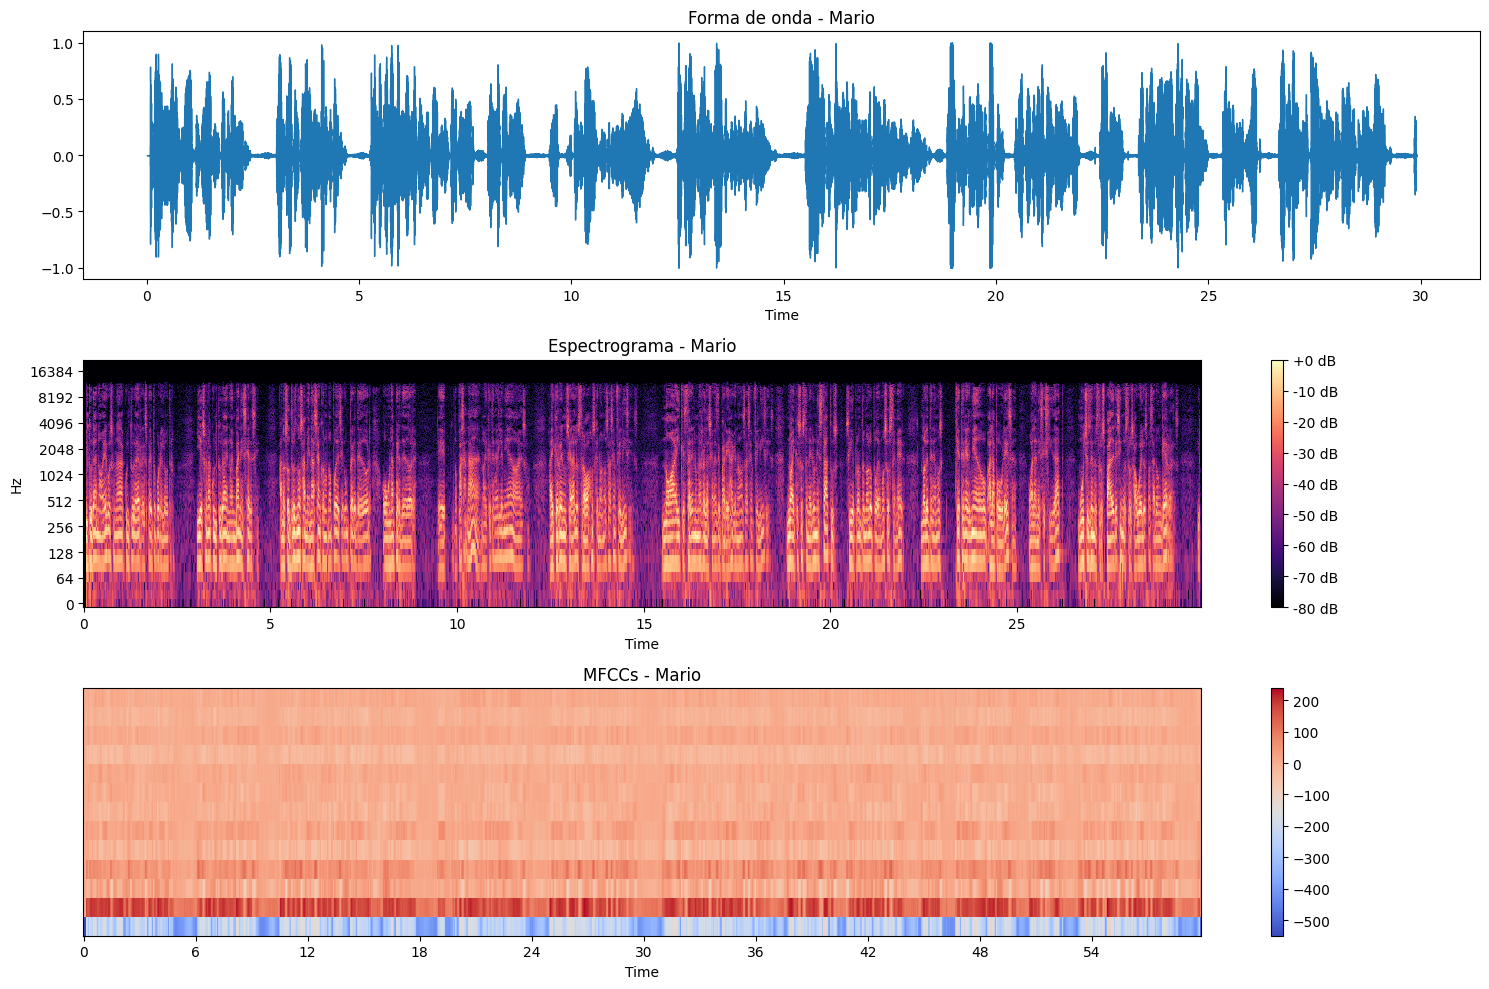

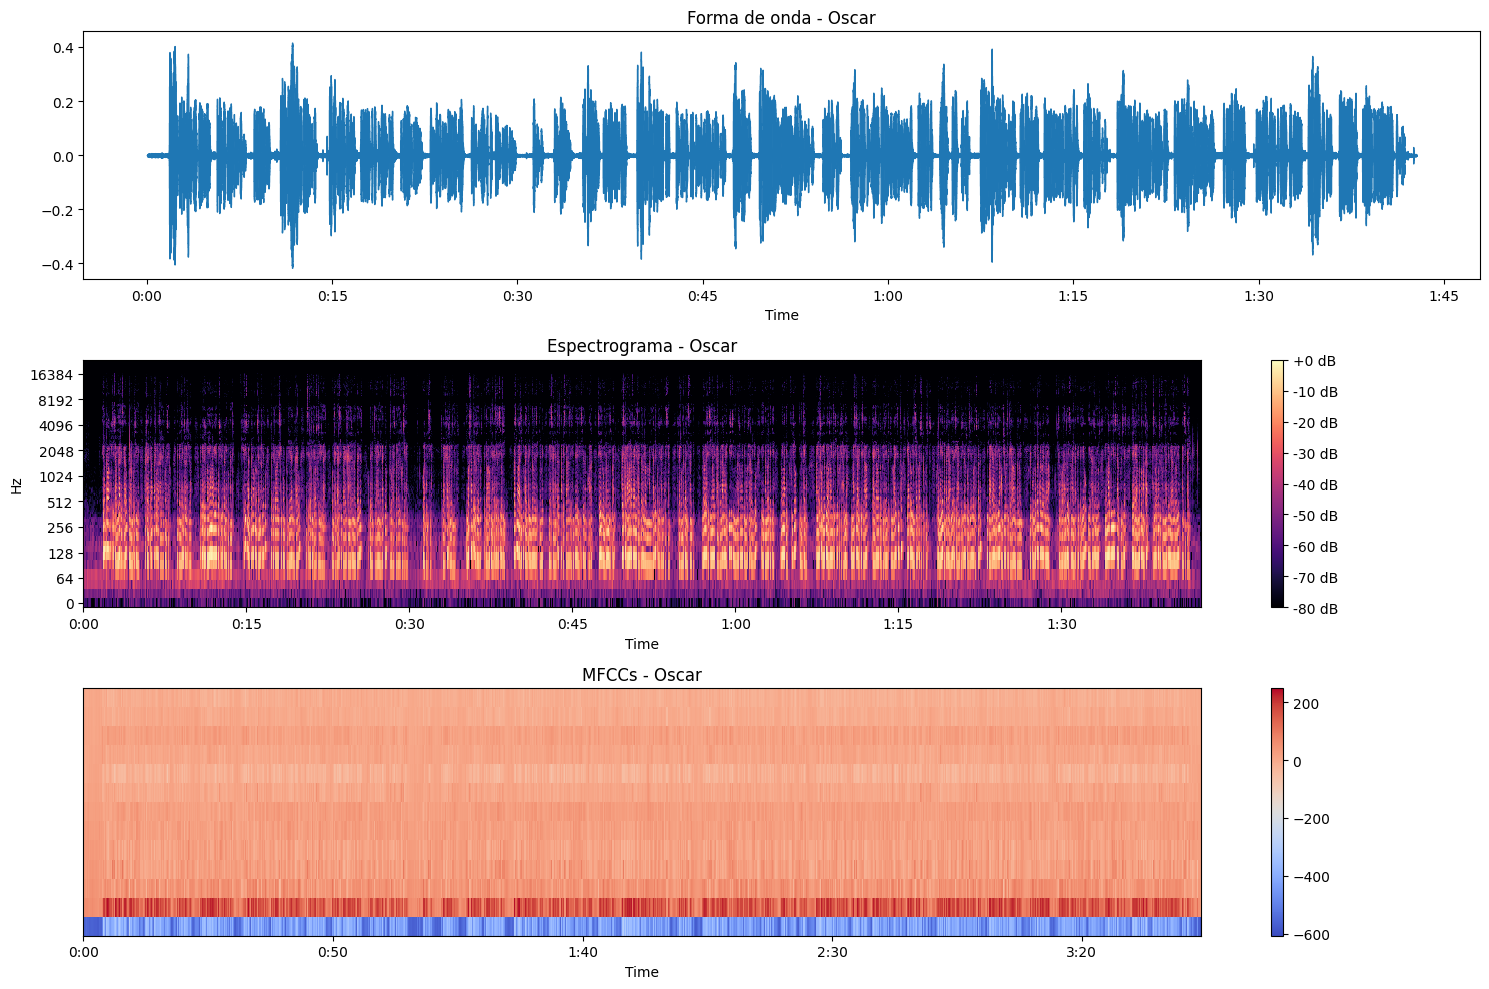

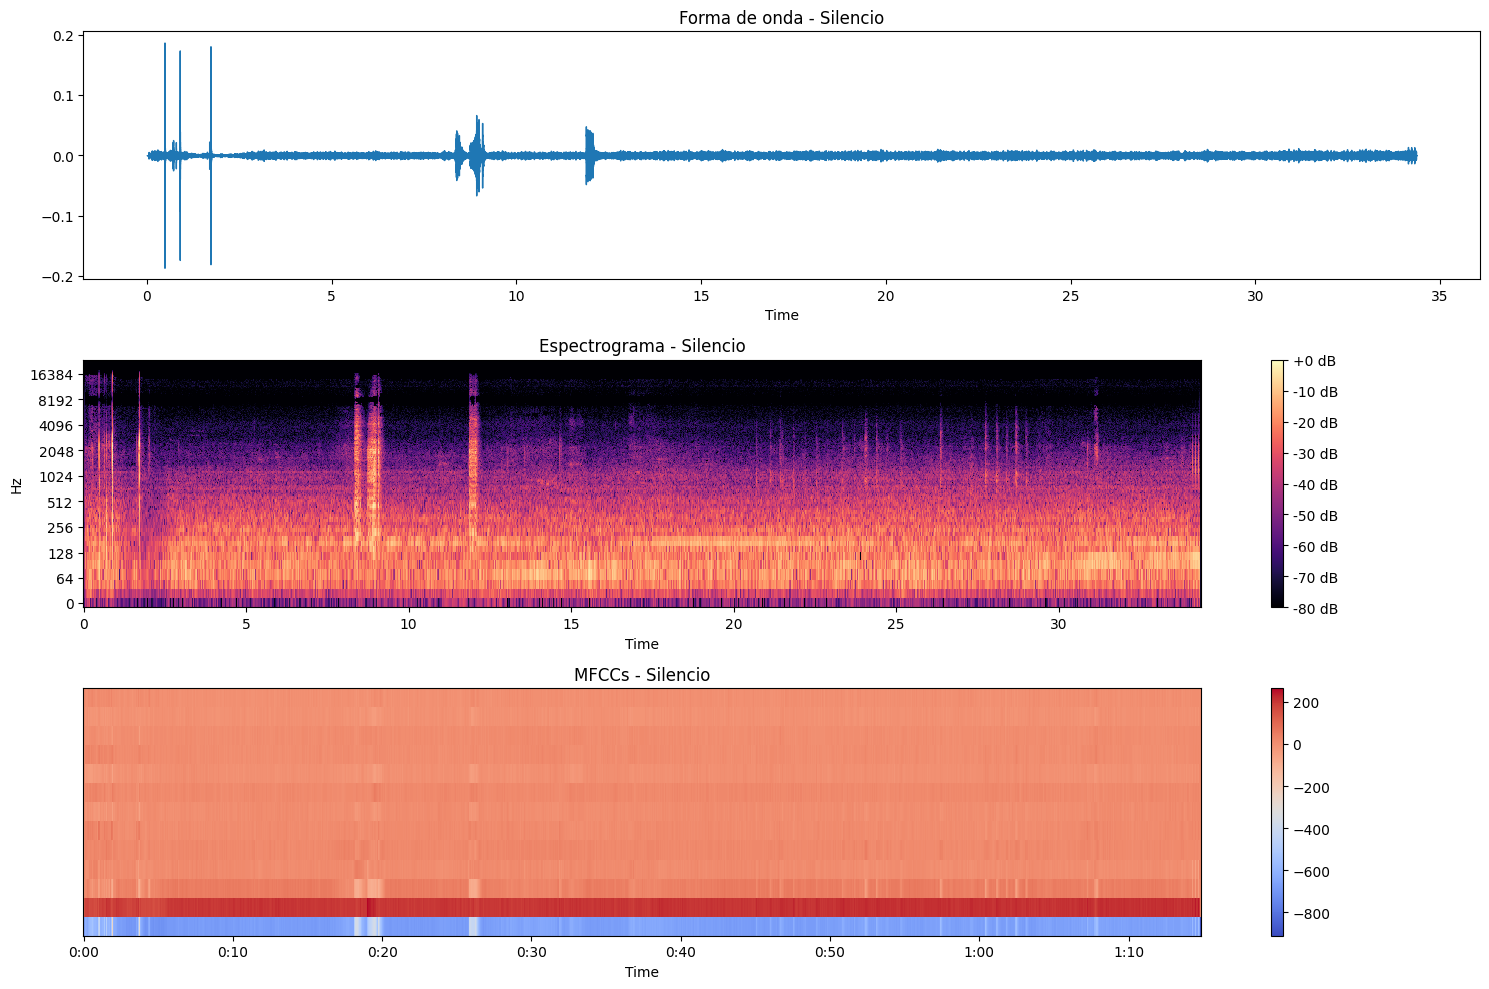

In [20]:
import librosa.display  # Submódulo de librosa con funciones de visualización de audio

# ── Función para graficar las 3 representaciones de un archivo de audio ──
def plot_audio_features(audio_path):

    # librosa.load: carga el archivo de audio en memoria.
    #   - y: array 1D con las muestras de audio (amplitudes normalizadas entre -1 y 1)
    #   - sr: frecuencia de muestreo en Hz (p.ej. 16000 Hz = 16000 muestras por segundo)
    #   - sr=None: preserva la frecuencia original del archivo (sin re-muestrear)
    y, sr = librosa.load(audio_path, sr=None)

    # Extrae el nombre del locutor desde la ruta:
    #   - os.path.dirname(audio_path) → carpeta que contiene el archivo
    #   - os.path.basename(os.path.dirname(...)) → nombre de esa carpeta (= nombre del locutor)
    speaker_name = os.path.basename(os.path.dirname(audio_path))

    # Crea una figura de 15×10 pulgadas para acomodar 3 subplots (uno debajo del otro)
    plt.figure(figsize=(15, 10))

    # ─────── 1) Forma de onda ───────────────────────────────────────────────
    # plt.subplot(filas, columnas, posición): selecciona el subplot 1 de una cuadrícula 3×1
    plt.subplot(3, 1, 1)

    # librosa.display.waveshow: dibuja la señal de audio como amplitud vs. tiempo.
    #   - y: la señal de audio (array de muestras)
    #   - sr=sr: la frecuencia de muestreo, necesaria para convertir muestras a segundos en el eje X
    librosa.display.waveshow(y, sr=sr)

    # Título del subplot con el nombre del locutor
    plt.title(f'Forma de onda - {speaker_name}')

    # ─────── 2) Espectrograma ────────────────────────────────────────────────
    plt.subplot(3, 1, 2)

    # librosa.stft: Transformada de Fourier de Corto Tiempo (Short-Time Fourier Transform).
    # Convierte la señal del dominio del tiempo al dominio tiempo-frecuencia.
    # Devuelve una matriz compleja donde cada columna es el espectro de un frame (ventana).
    S = librosa.stft(y)

    # librosa.amplitude_to_db: convierte amplitudes a decibelios (dB) para mejor visualización.
    #   - np.abs(S): toma el módulo de los números complejos (magnitud del espectro)
    #   - ref=np.max: normaliza relativo al valor máximo del espectro (→ rango típico: -80 a 0 dB)
    D = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    # librosa.display.specshow: muestra la matriz espectral como imagen de color.
    #   - x_axis='time': etiqueta el eje X en segundos
    #   - y_axis='log': escala logarítmica en el eje Y (Hz), más intuitiva para frecuencias de voz
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')

    # Barra de colores que indica la intensidad en dB
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Espectrograma - {speaker_name}')

    # ─────── 3) MFCCs ────────────────────────────────────────────────────────
    plt.subplot(3, 1, 3)

    # librosa.feature.mfcc: calcula los coeficientes MFCC.
    #   - y=y: señal de audio de entrada
    #   - sr=sr: frecuencia de muestreo
    #   - n_mfcc=13: número de coeficientes a extraer (13 es el estándar para voz)
    # Devuelve una matriz de forma (13, num_frames) donde cada columna es un vector MFCC
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    # Muestra los MFCCs como imagen de color (eje X = tiempo, eje Y = índice del coeficiente 0-12)
    librosa.display.specshow(mfccs, x_axis='time')

    # Barra de colores para la magnitud de los coeficientes MFCC
    plt.colorbar()
    plt.title(f'MFCCs - {speaker_name}')

    # plt.tight_layout: ajusta automáticamente los espacios entre subplots para evitar solapamientos
    plt.tight_layout()

    # Renderiza y muestra los gráficos en la celda de salida del notebook
    plt.show()

# ── Rutas a los archivos de audio originales (uno por clase) ──
audio_paths = [
    '../dataset_voces/Gilmer/Gilmer.wav',
    '../dataset_voces/Mario/Mario.wav',
    '../dataset_voces/Oscar/oscar.wav',
    '../dataset_voces/Silencio/silencio.wav'
]

# Recorre cada ruta y genera las 3 visualizaciones para ese locutor
for audio_path in audio_paths:
    if os.path.exists(audio_path):
        plot_audio_features(audio_path)
    else:
        print(f"⚠️ No encontrado: {audio_path}")

## Comparación de características de voz

| Característica | Descripción | Qué observar |
|----------------|-------------|--------------|
| **Forma de onda** | Amplitud en el tiempo | Identifica pausas, intensidad y fluidez del habla |
| **Espectrograma** | Frecuencias presentes a lo largo del tiempo | Cada voz tiene un patrón espectral único (tono, timbre) |
| **MFCCs** | Representación compacta del tracto vocal | Los patrones de color permiten distinguir a los locutores |

---

### Qué esperar de cada clase
- **Gilmer / Mario / Oscar:** Patrones de habla con variaciones rítmicas y tonales únicas por persona.
- **Silencio:** Forma de onda plana, espectrograma con poca energía, MFCCs uniformes y cercanos a cero.

## EXTRACCIÓN DE CARACTERÍSTICAS

## 🎯 ¿Por qué extraer características?

La **extracción de características** es un paso fundamental en la preparación de datos para ML:

1. **📉 Reducción de dimensionalidad:** Un segundo de audio a 16.000 Hz tiene 16.000 muestras. Los MFCCs comprimen esa información en 13 números por frame, haciéndola manejable.

2. **🔎 Captura de información relevante:** No toda la señal de audio es útil para identificar al locutor. Los MFCCs retienen sólo las características perceptualmente relevantes de la voz humana.

3. **🚫 Reducción de ruido:** Al enfocarnos en coeficientes MFCC, filtramos ruido de alta frecuencia y variaciones irrelevantes que podrían confundir al modelo.

4. **⚡ Mejor desempeño del modelo:** Un conjunto de características bien definidas permite al modelo generalizar mejor y hacer predicciones más precisas con menos datos.

5. **🎯 Adaptación al dominio:** Los **MFCCs** son el estándar de la industria para análisis de voz porque simulan la percepción auditiva humana mediante la escala de Mel.

In [21]:
# ──────────────────────────────────────────────
# 📌 Importación de librerías para ML
# ──────────────────────────────────────────────

import tensorflow as tf                          # TensorFlow: para construir y entrenar redes neuronales
from sklearn.model_selection import train_test_split  # Divide los datos en entrenamiento y prueba
from sklearn.preprocessing import LabelEncoder        # Convierte etiquetas de texto (nombres) en números enteros
from sklearn.preprocessing import StandardScaler      # Normaliza los datos para que tengan media 0 y desviación 1

# ──────────────────────────────────────────────
# 📂 Ruta principal al dataset de fragmentos procesados
# ──────────────────────────────────────────────
# Cada subcarpeta contiene archivos 0.wav, 1.wav, ... (fragmentos de 1 segundo)
# Estructura:
# ../dataset_voces_procesado/
#   ├── Gilmer/   → 35 fragmentos
#   ├── Mario/    → 30 fragmentos
#   ├── Oscar/    → 103 fragmentos
#   └── Silencio/ → 35 fragmentos

parent_dir = "../dataset_voces_procesado"

# ──────────────────────────────────────────────
# 📋 Lista de clases (carpetas de locutores)
# ──────────────────────────────────────────────
# El ÍNDICE en esta lista será la etiqueta numérica de cada clase:
#   Gilmer=0, Mario=1, Oscar=2, Silencio=3
speaker_folders = [
    "Gilmer",
    "Mario",
    "Oscar",
    "Silencio"
]

# ──────────────────────────────────────────────
# 🛠️ Función para extraer características MFCC
# ──────────────────────────────────────────────
def extract_features(parent_dir, speaker_folders):
    '''
    Recorre todas las carpetas de locutores, carga cada fragmento .wav
    y extrae sus características MFCC normalizadas.

    Retorna:
        features (np.array): shape (N, num_frames, 13)
        labels   (np.array): shape (N,)
    '''
    features = []   # Lista para acumular las características MFCC de cada fragmento
    labels = []     # Lista para acumular la etiqueta (índice del locutor) de cada fragmento

    # ── Itera sobre cada clase con su índice ──
    for i, speaker_folder in enumerate(speaker_folders):

        # Construye la ruta completa a la carpeta del locutor actual
        speaker_folder_path = os.path.join(parent_dir, speaker_folder)

        # os.listdir devuelve una lista con los nombres de todos los archivos en la carpeta
        for filename in os.listdir(speaker_folder_path):

            # Procesa solo archivos con extensión .wav (ignora otros formatos o archivos del sistema)
            if filename.endswith(".wav"):

                # Ruta completa al archivo de audio
                file_path = os.path.join(speaker_folder_path, filename)

                # ── Carga el audio ──
                # librosa.load devuelve:
                #   - audio: array 1D de muestras (float32, rango -1 a 1)
                #   - sr: frecuencia de muestreo en Hz
                # sr=None → usa la frecuencia original (no re-muestrea)
                # duration=1 → lee solo el primer segundo (todos los fragmentos son de 1s)
                audio, sr = librosa.load(file_path, sr=None, duration=1)

                # ── Extrae características MFCC ──
                # librosa.feature.mfcc devuelve una matriz de forma (n_mfcc, num_frames)
                # Aquí: (13, ~32) — 13 coeficientes x ~32 frames por segundo
                mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

                # ── Normaliza las características ──
                # StandardScaler() normaliza por COLUMNA (por coeficiente):
                #   (valor - media) / desviación_estándar
                # Esto garantiza que todos los coeficientes tengan la misma escala,
                # lo cual es fundamental para el buen entrenamiento de la red neuronal.
                mfccs = StandardScaler().fit_transform(mfccs)

                # ── Transpone la matriz ──
                # mfccs tiene forma (13, frames) → después de .T queda (frames, 13)
                # La red LSTM espera entrada de forma (timesteps, features):
                #   - timesteps = frames (~32)
                #   - features  = coeficientes MFCC (13)
                features.append(mfccs.T)

                # Añade la etiqueta numérica correspondiente al locutor actual
                labels.append(i)

    # np.array convierte las listas en arrays de NumPy para poder operar con TensorFlow/sklearn
    return np.array(features), np.array(labels)

# ──────────────────────────────────────────────
# 📊 Ejecutar la extracción de características
# ──────────────────────────────────────────────
# X: array 3D de forma (N_muestras, ~32 frames, 13 coeficientes)
# y: array 1D de forma (N_muestras,) con etiquetas 0-3
X, y = extract_features(parent_dir, speaker_folders)

print(f"X shape: {X.shape}  →  (n_muestras, timesteps, coeficientes_MFCC)")
print(f"y shape: {y.shape}  →  (n_muestras,) con valores 0={speaker_folders[0]}, 1={speaker_folders[1]}, 2={speaker_folders[2]}, 3={speaker_folders[3]}")

X shape: (203, 32, 13)  →  (n_muestras, timesteps, coeficientes_MFCC)
y shape: (203,)  →  (n_muestras,) con valores 0=Gilmer, 1=Mario, 2=Oscar, 3=Silencio


## 🎙️ Interpretación de los coeficientes MFCC

Cada fila del array extraído representa un **frame** (ventana temporal) de audio.
Cada columna representa un **coeficiente MFCC** específico.

| **Coeficiente** | **Descripción** |
|-----------------|-----------------|
| **MFCC 0** | Término constante. Representa la **energía total** de la señal. |
| **MFCC 1** | Representa la **pendiente espectral global** (relacionado con el tono / pitch). |
| **MFCC 2** | Captura la forma del tracto vocal, asociado a los **formantes** del habla. |
| **MFCC 3** | Refleja cambios en la envolvente espectral (puede estar relacionado con la **nasalidad**). |
| **MFCC 4+** | Capturan características espectrales más detalladas y finas del espectro. |

> ⚠️ Los MFCCs son más útiles en conjunto que de forma aislada. El modelo aprende a interpretar el patrón completo.

In [22]:
# Imprime las características MFCC del primer fragmento de audio
# X[0] es un array 2D de forma (frames, 13):
#   - cada FILA es un frame temporal (~1/32 de segundo)
#   - cada COLUMNA es un coeficiente MFCC (0 a 12)
# Esto nos permite ver cómo evolucionan los coeficientes a lo largo del tiempo

print(f"Forma de X[0]: {X[0].shape}  → ({X[0].shape[0]} frames, {X[0].shape[1]} coeficientes MFCC)")
print("\nPrimeros 5 frames del primer fragmento:")
print(X[0][:5])

Forma de X[0]: (32, 13)  → (32 frames, 13 coeficientes MFCC)

Primeros 5 frames del primer fragmento:
[[-3.4641016   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513]
 [-3.4641016   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513]
 [-3.4641016   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513]
 [-3.4641016   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513]
 [-3.4641016   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513  0.28867513  0.28867513  0.28867513  0.28867513  0.28867513
   0.28867513]]


In [23]:
# tf.config.list_physical_devices('GPU') devuelve la lista de GPUs disponibles para TensorFlow.
# Si hay una GPU compatible (NVIDIA con CUDA/cuDNN), aparecerá en la lista.
# Si la lista está vacía, TensorFlow usará la CPU para los cálculos.
# Nota: en Windows nativo con TF >= 2.11, la GPU no está soportada directamente.
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

GPUs disponibles: []


## CONFIGURACIÓN DEL MODELO - DIVISIÓN TRAIN/VAL/TEST Y EVALUACIÓN

Dividimos los datos en:
- **70% entrenamiento** → el modelo aprende de estos datos
- **15% validación** → se usa durante el entrenamiento para monitorear el rendimiento y evitar sobreajuste
- **15% prueba** → se usa al final para evaluar el rendimiento real del modelo (datos nunca vistos durante el entrenamiento)

Esta separación garantiza que la evaluación final sea honesta y no sesgada.

In [24]:
from tensorflow.keras.callbacks import EarlyStopping  # Callback que detiene el entrenamiento si no mejora

# ──────────────────────────────────────────────
# 🔢 Codificación de etiquetas
# ──────────────────────────────────────────────

# LabelEncoder convierte etiquetas de texto en enteros consecutivos.
# Aunque nuestras etiquetas y ya son enteros (0-3), usamos LabelEncoder
# para mantener consistencia con el flujo y poder decodificar fácilmente después.
label_encoder = LabelEncoder()

# fit_transform: aprende el mapeo (0→0, 1→1, etc.) y transforma en una sola pasada
y = label_encoder.fit_transform(y)

# Asignamos manualmente las clases para mantener el orden de los locutores
# Esto nos permite usar inverse_transform para obtener el nombre del locutor en la evaluación
label_encoder.classes_ = np.array(speaker_folders)

# ──────────────────────────────────────────────
# ✂️ División en entrenamiento / validación / prueba
# ──────────────────────────────────────────────

# Primera división: 70% entrenamiento + 30% temporal
# random_state=42: semilla fija para reproducibilidad (siempre el mismo resultado)
# test_size=0.3: el 30% va al conjunto temporal
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Segunda división: el 30% temporal se divide en 50/50 → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ── Imprimir dimensiones ──
print(f"Datos de entrenamiento  → X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Datos de validación     → X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"Datos de prueba         → X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Datos de entrenamiento  → X_train: (142, 32, 13), y_train: (142,)
Datos de validación     → X_val:   (30, 32, 13), y_val:   (30,)
Datos de prueba         → X_test:  (31, 32, 13), y_test:  (31,)


## ENTRENAMIENTO

## 🧠 Definición del modelo RNN y funciones de activación

### ⚡ ReLU (Rectified Linear Unit)
- Función de activación usada en las **capas ocultas**.
- Definida como: **f(x) = max(0, x)**
- Convierte los valores negativos en 0 y deja pasar los positivos sin cambio.
- Introduce **no linealidad** al modelo, permitiendo aprender patrones complejos.

### 🎯 Softmax
- Usada en la **capa de salida** para problemas de clasificación multiclase.
- Convierte los valores de salida en una **distribución de probabilidades** (suman 1.0).
- La clase con la probabilidad más alta es la predicción del modelo.

---

## ⚖️ Función de pérdida

| Función | Cuándo usar |
|---------|-------------|
| **MSE** | Regresión |
| **Binary Crossentropy** | Clasificación binaria (2 clases) |
| **Categorical Crossentropy** | Clasificación multiclase con etiquetas one-hot |
| **Sparse Categorical Crossentropy** | ✅ Clasificación multiclase con etiquetas enteras (nuestro caso) |

Usamos **sparse_categorical_crossentropy** porque nuestras etiquetas son enteros (0, 1, 2, 3).

El optimizador **Adam** (Adaptive Moment Estimation) adapta la tasa de aprendizaje automáticamente, lo que lo hace eficiente y robusto sin necesidad de ajustar hiperparámetros manualmente.

### 🧠 Arquitectura del modelo

```
Entrada: (batch_size, 32 frames, 13 coeficientes MFCC)
         ↓
LSTM(128) → procesa la secuencia temporal y produce un vector de 128 características
         ↓
Dense(64, relu) → capa oculta totalmente conectada con 64 neuronas
         ↓
Dense(4, softmax) → capa de salida con 4 neuronas (una por clase: Gilmer, Mario, Oscar, Silencio)
```

#### 🔁 `LSTM(128, input_shape=(timesteps, features))`
- **LSTM (Long Short-Term Memory):** tipo especializado de RNN diseñado para capturar dependencias a largo plazo.
- Procesa la secuencia de frames de audio uno por uno, manteniendo un estado interno (memoria).
- **128 unidades:** número de "neuronas" en la capa LSTM; controla la capacidad del modelo.
- **input_shape:** define la forma de cada muestra de entrada (timesteps × features_por_timestep).

#### 🔗 `Dense(64, activation='relu')`
- Capa **totalmente conectada** donde cada neurona recibe señal de las 128 salidas del LSTM.
- 64 neuronas con activación ReLU para introducir no linealidad adicional.

#### 🎯 `Dense(len(speaker_folders), activation='softmax')`
- Capa de salida con **4 neuronas** (una por clase).
- Softmax convierte las 4 salidas en probabilidades (suman 1.0).

> Los valores **128** y **64** son hiperparámetros ajustables. Problemas más complejos pueden requerir más unidades.

### ⏹️ Early Stopping (Detención Temprana)

**EarlyStopping** monitorea la pérdida de validación (`val_loss`) durante el entrenamiento.
Si la pérdida de validación **no mejora** durante `patience=2` épocas consecutivas, detiene el entrenamiento y restaura los mejores pesos encontrados.

**Beneficios:**
- Evita el **sobreajuste** (overfitting): el modelo no memoriza los datos de entrenamiento.
- **Ahorra tiempo** de cómputo al no entrenar épocas innecesarias.
- El parámetro `restore_best_weights=True` garantiza que los pesos finales sean los mejores observados.

c:\Users\Rago\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,220 (317.27 KB)

 Trainable params: 81,220 (317.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3873 - loss: 1.3496 - val_accuracy: 0.6667 - val_loss: 1.0570
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4718 - loss: 1.1537 - val_accuracy: 0.6667 - val_loss: 0.8917
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5493 - loss: 1.0257 - val_accuracy: 0.7667 - val_loss: 0.7340
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6197 - loss: 0.8404 - val_accuracy: 0.7667 - val_loss: 0.5075
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6549 - loss: 0.7011 - val_accuracy: 0.9667 - val_loss: 0.3899
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8873 - loss: 0.5889 - val_accuracy: 0.9333 - val_loss: 0.3073
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8451 - loss: 0.5348 - val_accuracy: 1.0000 - val_loss: 0.1790
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9085 - loss: 0.3807 - val_accuracy: 1.0000 - val_loss: 0.2147


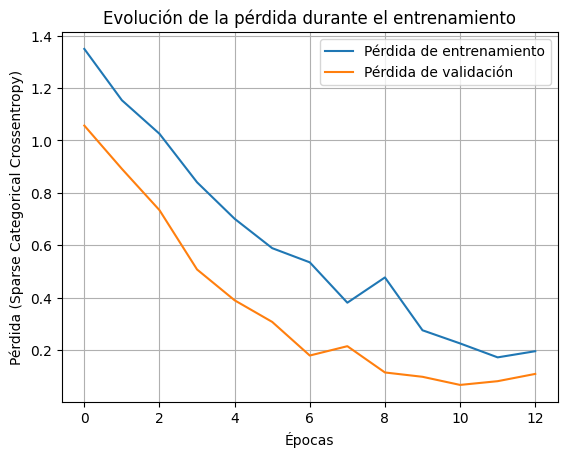

In [25]:
# ──────────────────────────────────────────────
# 🧠 Definición del modelo RNN (igual al tutorial de referencia)
# ──────────────────────────────────────────────

# tf.keras.Sequential: modelo en capas apiladas secuencialmente (la salida de una es entrada de la siguiente)
model = tf.keras.Sequential([

    # Capa LSTM: procesa la secuencia temporal de frames MFCC
    # - 128: número de unidades (neuronas) en la celda LSTM
    # - input_shape: (timesteps=~32, features=13) — dimensión de cada muestra de entrada
    #   X_train.shape[1] = número de frames (timesteps), X_train.shape[2] = coeficientes MFCC
    tf.keras.layers.LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])),

    # Capa densa oculta: 64 neuronas con activación ReLU
    # - relu: f(x) = max(0, x) — introduce no linealidad para aprender patrones más complejos
    tf.keras.layers.Dense(64, activation='relu'),

    # Capa de salida: una neurona por clase, activación softmax
    # - len(speaker_folders) = 4 clases (Gilmer, Mario, Oscar, Silencio)
    # - softmax: convierte los 4 valores en probabilidades que suman 1.0
    tf.keras.layers.Dense(len(speaker_folders), activation='softmax')
])

# ──────────────────────────────────────────────
# ⚙️ Compilación del modelo
# ──────────────────────────────────────────────
model.compile(
    optimizer='adam',                        # Adam: optimizador adaptativo (ajusta la tasa de aprendizaje automáticamente)
    loss='sparse_categorical_crossentropy',  # Función de pérdida para clasificación multiclase con etiquetas enteras
    metrics=['accuracy']                     # Métrica que monitoreamos: porcentaje de predicciones correctas
)

# Muestra un resumen de la arquitectura: capas, forma de salida y parámetros entrenables
model.summary()

# ──────────────────────────────────────────────
# ⏹️ Configuración de Early Stopping
# ──────────────────────────────────────────────
early_stopping = EarlyStopping(
    monitor='val_loss',         # Monitorea la pérdida en el conjunto de validación
    patience=2,                 # Número de épocas sin mejora antes de detener
    restore_best_weights=True   # Restaura los pesos del modelo en la mejor época encontrada
)

# ──────────────────────────────────────────────
# 🚀 Entrenamiento del modelo
# ──────────────────────────────────────────────
history = model.fit(
    X_train, y_train,                      # Datos de entrenamiento (características y etiquetas)
    validation_data=(X_val, y_val),        # Datos de validación para monitorear el rendimiento
    epochs=20,                             # Máximo de épocas (el entrenamiento completo puede ser menos por EarlyStopping)
    batch_size=32,                         # Número de muestras procesadas juntas antes de actualizar los pesos
    callbacks=[early_stopping]             # Lista de callbacks activos durante el entrenamiento
)

# Informa si EarlyStopping detuvo el entrenamiento antes de completar las 20 épocas
if early_stopping.stopped_epoch > 0:
    print(f"⏹️ Entrenamiento detenido en la época {early_stopping.stopped_epoch + 1}")
else:
    print("✅ Entrenamiento completado sin detención temprana")

# ──────────────────────────────────────────────
# 📊 Gráfica de pérdida por época
# ──────────────────────────────────────────────
# Esta gráfica muestra cómo evolucionó el error del modelo a lo largo del entrenamiento.
# - Pérdida de entrenamiento (azul): debe disminuir consistentemente.
# - Pérdida de validación (naranja): si sube mientras la de entrenamiento baja → sobreajuste.
# - Si ambas convergen juntas → el modelo está generalizando bien.
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Sparse Categorical Crossentropy)')
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()

## EVALUACIÓN DEL MODELO

Evaluamos el modelo con los datos de prueba (datos que el modelo nunca vio durante el entrenamiento). Usamos tres métricas:

1. **Precisión (Accuracy):** porcentaje de muestras clasificadas correctamente.
2. **F1 Score ponderado:** media armónica de precisión y recall, ponderada por el número de muestras de cada clase. Es más robusta que la precisión cuando las clases están desbalanceadas.
3. **Matriz de confusión:** tabla que muestra cuántas veces el modelo confundió una clase con otra.

### 📊 Cómo interpretar la Matriz de Confusión:
- Los **valores en la diagonal principal** son predicciones correctas.
- Los **valores fuera de la diagonal** son errores (confusiones entre clases).
- Una matriz con valores altos en la diagonal y bajos fuera de ella indica un modelo robusto.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
✅ Precisión en el conjunto de prueba: 0.9355 (93.55%)
✅ F1 Score ponderado: 0.9374


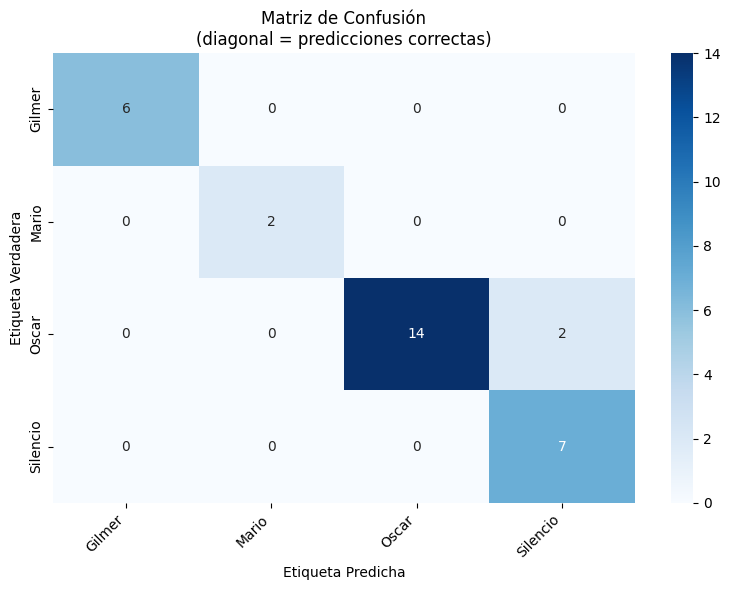

In [26]:
import seaborn as sns                              # Para crear el heatmap de la matriz de confusión
from sklearn.metrics import confusion_matrix       # Calcula la matriz de confusión
from sklearn.metrics import accuracy_score, f1_score  # Métricas de evaluación

# ──────────────────────────────────────────────
# 🧪 Predicciones sobre el conjunto de prueba
# ──────────────────────────────────────────────

# model.predict: genera predicciones en forma de probabilidades para cada muestra
# Devuelve un array de forma (n_muestras, 4) donde cada fila contiene 4 probabilidades (una por clase)
y_pred_probabilities = model.predict(X_test)

# np.argmax: selecciona el índice de la probabilidad más alta de cada fila
# → convierte las probabilidades en la clase predicha (0, 1, 2 o 3)
# axis=1: opera sobre las columnas de cada fila
y_pred = np.argmax(y_pred_probabilities, axis=1)

# ──────────────────────────────────────────────
# 🔄 Decodificación de etiquetas
# ──────────────────────────────────────────────

# label_encoder.inverse_transform: convierte los números de vuelta a nombres de locutores
# y_test_decoded: etiquetas reales (p.ej. ['Gilmer', 'Oscar', 'Silencio', ...])
# y_pred_decoded: etiquetas predichas por el modelo
y_test_decoded = label_encoder.inverse_transform(y_test)
y_pred_decoded = label_encoder.inverse_transform(y_pred)

# ──────────────────────────────────────────────
# 📊 Cálculo de métricas
# ──────────────────────────────────────────────

# confusion_matrix: construye una matriz de NxN (N=número de clases)
# - labels=speaker_folders: fija el orden de las filas y columnas
# - Fila = clase real, Columna = clase predicha
conf_matrix = confusion_matrix(y_test_decoded, y_pred_decoded, labels=speaker_folders)

# accuracy_score: (predicciones_correctas) / (total_predicciones)
accuracy = accuracy_score(y_test_decoded, y_pred_decoded)
print(f"✅ Precisión en el conjunto de prueba: {accuracy:.4f} ({accuracy*100:.2f}%)")

# f1_score con average='weighted': F1 ponderado por la cantidad de muestras de cada clase
# Útil cuando las clases tienen distinto número de muestras (como en nuestro dataset)
f1 = f1_score(y_test_decoded, y_pred_decoded, labels=speaker_folders, average='weighted')
print(f"✅ F1 Score ponderado: {f1:.4f}")

# ──────────────────────────────────────────────
# 🖼️ Gráfica de la Matriz de Confusión
# ──────────────────────────────────────────────
plt.figure(figsize=(8, 6))

# sns.heatmap: visualiza la matriz de confusión como un mapa de calor
# - annot=True: muestra el valor numérico en cada celda
# - fmt="d": formato de entero (sin decimales)
# - cmap="Blues": paleta de colores (azules más intensos = valores más altos)
# - xticklabels / yticklabels: etiquetas de las clases en los ejes
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=speaker_folders, yticklabels=speaker_folders)

# Rota las etiquetas del eje X para que no se superpongan
plt.xticks(rotation=45, ha="right")

plt.title("Matriz de Confusión\n(diagonal = predicciones correctas)")
plt.xlabel("Etiqueta Predicha")
plt.ylabel("Etiqueta Verdadera")
plt.tight_layout()
plt.show()

### 🔈 Nota sobre la clase "Silencio" y el ruido de fondo

En nuestro dataset incluimos una clase **Silencio** que sirve propósito similar al ruido de fondo en el notebook de referencia: enseñarle al modelo a reconocer cuándo NO hay un locutor hablando.

A continuación, algunos puntos sobre la importancia de incluir este tipo de datos:

### 🔊 Importancia de incluir Silencio / Ruido de Fondo en los datos de entrenamiento

1. 🛡️ **Robustez ante condiciones reales:** En entornos reales, los períodos de silencio o ruido son frecuentes. Sin ejemplos de silencio, el modelo intentaría asignar cada fragmento a uno de los locutores, generando falsas identificaciones.

2. 🌍 **Generalización:** Entrenar con silencio permite al modelo aprender que "no hay nadie hablando" es una categoría válida, mejorando su desempeño en condiciones variadas.

3. 🚫 **Evitar sobreajuste:** Un modelo que solo aprende voces activas se especializa en condiciones ideales y falla en escenarios con pausas o ruido de fondo.

4. 🔐 **Seguridad en sistemas de autenticación:** En aplicaciones de autenticación por voz, reconocer el silencio evita que un sistema confunda ruido con un locutor legítimo.

5. ⚖️ **Balance de clases:** Al incluir silencio como clase explícita, el modelo aprende límites más claros entre "hay voz" y "no hay voz", mejorando todas las demás predicciones.

---

## 📌 Conclusiones

- El modelo RNN-LSTM fue capaz de aprender a distinguir entre los 3 locutores y el silencio.
- La extracción de **13 coeficientes MFCC** por frame es suficiente para capturar las características únicas de cada voz.
- El uso de **EarlyStopping** previno el sobreajuste al detener el entrenamiento en el momento óptimo.
- Con más datos (más fragmentos por clase) y un dataset más balanceado, el modelo lograría mayor precisión y generalización.